In [2]:
from pathlib import Path
from math import gcd
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import resample_poly

import tensorflow as tf
import tensorflow_hub as hub

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)

C:\Users\benja\anaconda3\envs\BDE\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [3]:
AUDIO_DIR = Path('.')
PROJECT_ROOT = Path('..')
DATA_DIR = PROJECT_ROOT / 'data'
META_DIR = DATA_DIR / 'metadata'

MODEL_MANIFEST_PATH = META_DIR / 'benchmark_2_audio_model_manifest.csv'
MODELS_DIR = AUDIO_DIR / 'models'
RESULTS_DIR = AUDIO_DIR / 'results'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

YAMNET_HANDLE = 'https://tfhub.dev/google/yamnet/1'
YAMNET_SAMPLE_RATE = 16_000

CONTEXT_SECONDS = 1.0

TARGET_ANIMAL_RECALL = 0.95
EMBEDDING_POOL = 'mean'
RANDOM_SEED = 42

CONTEXT_TAG = str(CONTEXT_SECONDS).replace('.', 'p')
EMBEDDING_CACHE_PATH = RESULTS_DIR / f'yamnet_embeddings_{CONTEXT_TAG}s.npz'
MODEL_PATH = MODELS_DIR / f'yamnet_logreg_{CONTEXT_TAG}s.joblib'
METRICS_PATH = RESULTS_DIR / f'yamnet_metrics_{CONTEXT_TAG}s.csv'
CONFIG_PATH = RESULTS_DIR / f'yamnet_config_{CONTEXT_TAG}s.json'

print('Manifest:', MODEL_MANIFEST_PATH)
print('Context:', CONTEXT_SECONDS, 's')
print('Target animal recall:', TARGET_ANIMAL_RECALL)

Manifest: ..\data\metadata\benchmark_2_audio_model_manifest.csv
Context: 1.0 s
Target animal recall: 0.95


In [4]:
manifest = pd.read_csv(MODEL_MANIFEST_PATH)

required_columns = {
    'sample_id', 'event_id', 'file_id', 'anchor_s', 'duration',
    'binary_label', 'label_name', 'site_id', 'cam_id',
    'audio_path', 'dataset_split',
}

missing_columns = required_columns - set(manifest.columns)
assert not missing_columns, (
    'The modeling manifest is missing columns: '
    f'{sorted(missing_columns)}. Run 01_Prepare_Audio_Dataset.ipynb first.'
)

assert set(manifest['dataset_split'].unique()) <= {'train', 'val', 'test'}
assert manifest.groupby('event_id')['dataset_split'].nunique().max() == 1

eligible = manifest[manifest['duration'] >= CONTEXT_SECONDS].copy()

print('All manifest samples:', len(manifest))
print('Eligible samples:', len(eligible))
print('Eligible events:', eligible['event_id'].nunique())

display(
    eligible.groupby(['dataset_split', 'label_name'])
    .agg(
        samples=('sample_id', 'count'),
        events=('event_id', 'nunique'),
        files=('file_id', 'nunique'),
    )
)


All manifest samples: 908
Eligible samples: 908
Eligible events: 389


samples  events  files
dataset_split label_name                        
test          animal          123      57    117
              background       84      28     48
train         animal          436     203    425
              background      120      40     59
val           animal          115      51    111
              background       30      10     19

In [5]:
def choose_window(anchor_s, duration_s, context_s):
    if duration_s < context_s:
        raise ValueError(
            f'Source duration {duration_s:.3f}s is shorter than requested context {context_s:.3f}s.'
        )

    start_s = np.clip(
        anchor_s - context_s / 2,
        0,
        duration_s - context_s,
    )
    end_s = start_s + context_s
    return float(start_s), float(end_s)

In [6]:
def resample_waveform(waveform, source_sr, target_sr):
    if source_sr == target_sr:
        return waveform.astype(np.float32, copy=False)

    divisor = gcd(int(source_sr), int(target_sr))
    up = target_sr // divisor
    down = source_sr // divisor
    resampled = resample_poly(waveform, up=up, down=down)
    return resampled.astype(np.float32)

In [7]:
def load_yamnet_waveform(row, context_s=CONTEXT_SECONDS):
    audio_path = Path(row['audio_path'])

    if not audio_path.exists():
        raise FileNotFoundError(f'Missing cached audio: {audio_path}')

    with sf.SoundFile(audio_path) as audio_file:
        source_sr = int(audio_file.samplerate)
        actual_duration = len(audio_file) / source_sr

        duration_s = min(float(row['duration']), float(actual_duration))
        start_s, end_s = choose_window(
            anchor_s=float(row['anchor_s']),
            duration_s=duration_s,
            context_s=context_s,
        )

        start_frame = round(start_s * source_sr)
        frames_to_read = round(context_s * source_sr)
        audio_file.seek(start_frame)
        waveform = audio_file.read(
            frames=frames_to_read,
            dtype='float32',
            always_2d=False,
        )

    if waveform.ndim == 2:
        waveform = waveform.mean(axis=1)

    waveform = resample_waveform(waveform, source_sr, YAMNET_SAMPLE_RATE)

    target_samples = round(context_s * YAMNET_SAMPLE_RATE)
    if len(waveform) > target_samples:
        waveform = waveform[:target_samples]
    elif len(waveform) < target_samples:
        waveform = np.pad(waveform, (0, target_samples - len(waveform)))

    return np.clip(waveform, -1.0, 1.0).astype(np.float32)


In [8]:
yamnet = hub.load(YAMNET_HANDLE)

class_map_path = yamnet.class_map_path().numpy().decode('utf-8')
class_map = pd.read_csv(class_map_path)
class_names = class_map['display_name'].tolist()

print('YAMNet classes:', len(class_names))

animal_matches = [
    (i, name)
    for i, name in enumerate(class_names)
    if 'animal' in name.lower()
]

print("\nClasses containing 'animal':")
for item in animal_matches:
    print(item)

assert 'Animal' in class_names
ANIMAL_CLASS_INDEX = class_names.index('Animal')
print("\nExact 'Animal' class index:", ANIMAL_CLASS_INDEX)

YAMNet classes: 521

Classes containing 'animal':
(67, 'Animal')
(68, 'Domestic animals, pets')
(81, 'Livestock, farm animals, working animals')
(103, 'Wild animals')

Exact 'Animal' class index: 67


In [9]:
example_row = eligible.iloc[0]
example_waveform = load_yamnet_waveform(example_row)

scores, embeddings, spectrogram = yamnet(tf.convert_to_tensor(example_waveform))

print('Label:', example_row['label_name'])
print('Waveform shape:', example_waveform.shape)
print('Scores shape:', scores.shape)
print('Embeddings shape:', embeddings.shape)
print('Spectrogram shape:', spectrogram.shape)

clip_scores = scores.numpy().mean(axis=0)
top_indices = np.argsort(clip_scores)[-10:][::-1]

print('\nTop YAMNet classes:')
for idx in top_indices:
    print(f'{class_names[idx]:35s} {clip_scores[idx]:.4f}')

print("\nYAMNet 'Animal' score:", float(clip_scores[ANIMAL_CLASS_INDEX]))

Label: animal
Waveform shape: (16000,)
Scores shape: (2, 521)
Embeddings shape: (2, 1024)
Spectrogram shape: (144, 64)

Top YAMNet classes:
Silence                             0.9918
Sound effect                        0.0006
Inside, small room                  0.0002
Music                               0.0002
Outside, rural or natural           0.0002
Speech                              0.0001
Outside, urban or manmade           0.0001
Musical instrument                  0.0001
Inside, large room or hall          0.0001
Electronic music                    0.0000

YAMNet 'Animal' score: 3.970535999542335e-06


In [10]:
def extract_yamnet_features(df):
    embeddings_out = []
    animal_scores_out = []
    start_time = time.perf_counter()

    for count, (_, row) in enumerate(df.iterrows(), start=1):
        waveform = load_yamnet_waveform(row)
        scores, embeddings, _ = yamnet(tf.convert_to_tensor(waveform))

        scores_np = scores.numpy()
        embeddings_np = embeddings.numpy()

        if EMBEDDING_POOL == 'mean':
            pooled_embedding = embeddings_np.mean(axis=0)
        else:
            raise ValueError(f'Unknown EMBEDDING_POOL={EMBEDDING_POOL}')

        pooled_scores = scores_np.mean(axis=0)
        embeddings_out.append(pooled_embedding.astype(np.float32))
        animal_scores_out.append(float(pooled_scores[ANIMAL_CLASS_INDEX]))

        if count % 100 == 0 or count == len(df):
            elapsed = time.perf_counter() - start_time
            print(f'{count}/{len(df)} samples ({elapsed:.1f}s)')

    return (
        np.stack(embeddings_out),
        np.asarray(animal_scores_out, dtype=np.float32),
    )


In [11]:
if EMBEDDING_CACHE_PATH.exists():
    cached = np.load(EMBEDDING_CACHE_PATH, allow_pickle=True)
    cached_sample_ids = cached['sample_ids'].astype(str)

    if np.array_equal(
        cached_sample_ids,
        eligible['sample_id'].astype(str).to_numpy(),
    ):
        X = cached['embeddings']
        zero_shot_animal_score = cached['animal_scores']
        print('Loaded cached YAMNet features:', EMBEDDING_CACHE_PATH)
    else:
        raise RuntimeError(
            'Embedding cache exists but sample IDs do not match the current manifest. '
            'Delete the cache and rerun.'
        )
else:
    X, zero_shot_animal_score = extract_yamnet_features(eligible)
    np.savez_compressed(
        EMBEDDING_CACHE_PATH,
        embeddings=X,
        animal_scores=zero_shot_animal_score,
        sample_ids=eligible['sample_id'].astype(str).to_numpy(),
    )
    print('Saved YAMNet feature cache:', EMBEDDING_CACHE_PATH)

print('Embedding matrix:', X.shape)

100/908 samples (1.4s)
200/908 samples (2.8s)
300/908 samples (4.3s)
400/908 samples (5.9s)
500/908 samples (7.5s)
600/908 samples (9.1s)
700/908 samples (10.7s)
800/908 samples (12.2s)
900/908 samples (13.7s)
908/908 samples (13.9s)
Saved YAMNet feature cache: results\yamnet_embeddings_1p0s.npz
Embedding matrix: (908, 1024)


In [12]:
y = eligible['binary_label'].astype(int).to_numpy()
splits = eligible['dataset_split'].to_numpy()

train_mask = splits == 'train'
val_mask = splits == 'val'
test_mask = splits == 'test'

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print('Train:', X_train.shape)
print('Val:  ', X_val.shape)
print('Test: ', X_test.shape)

print('\nClass counts:')
for split_name, labels in [('train', y_train), ('val', y_val), ('test', y_test)]:
    unique, counts = np.unique(labels, return_counts=True)
    print(split_name, dict(zip(unique, counts)))


Train: (556, 1024)
Val:   (145, 1024)
Test:  (207, 1024)

Class counts:
train {np.int64(0): np.int64(120), np.int64(1): np.int64(436)}
val {np.int64(0): np.int64(30), np.int64(1): np.int64(115)}
test {np.int64(0): np.int64(84), np.int64(1): np.int64(123)}


In [13]:
def binary_gate_metrics(y_true, probabilities, threshold):
    y_true = np.asarray(y_true).astype(int)
    probabilities = np.asarray(probabilities)
    y_pred = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    animal_recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    background_rejection = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    overall_skip_rate = (y_pred == 0).mean()
    safe_skip_rate = tn / len(y_true)

    return {
        'threshold': float(threshold),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_animal': precision_score(y_true, y_pred, zero_division=0),
        'animal_recall': animal_recall,
        'false_negative_rate': 1 - animal_recall,
        'f1_animal': f1_score(y_true, y_pred, zero_division=0),
        'background_rejection': background_rejection,
        'overall_vision_skip_rate': overall_skip_rate,
        'safe_vision_skip_rate': safe_skip_rate,
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

In [14]:
def choose_threshold_for_recall(y_true, probabilities, target_recall=0.95):
    probabilities = np.asarray(probabilities)
    thresholds = np.unique(np.concatenate([[0.0], probabilities, [1.0]]))

    rows = [
        binary_gate_metrics(y_true, probabilities, threshold)
        for threshold in thresholds
    ]
    table = pd.DataFrame(rows)
    feasible = table[table['animal_recall'] >= target_recall].copy()

    if feasible.empty:
        raise RuntimeError(f'No threshold achieved recall >= {target_recall:.3f}')

    best = (
        feasible
        .sort_values(['background_rejection', 'threshold'], ascending=[False, False])
        .iloc[0]
    )

    return float(best['threshold']), table


In [15]:
zero_val = zero_shot_animal_score[val_mask]
zero_test = zero_shot_animal_score[test_mask]

zero_threshold, zero_val_curve = choose_threshold_for_recall(
    y_val, zero_val, TARGET_ANIMAL_RECALL
)

zero_val_metrics = binary_gate_metrics(y_val, zero_val, zero_threshold)
zero_test_metrics = binary_gate_metrics(y_test, zero_test, zero_threshold)

print('Zero-shot threshold:', zero_threshold)

display(pd.DataFrame([
    {'split': 'val', **zero_val_metrics},
    {'split': 'test', **zero_test_metrics},
]).round(4))

print('Validation ROC-AUC:', round(roc_auc_score(y_val, zero_val), 4))
print('Test ROC-AUC:', round(roc_auc_score(y_test, zero_test), 4))


Zero-shot threshold: 6.184774639343406e-19


,split,threshold,accuracy,precision_animal,animal_recall,false_negative_rate,f1_animal,background_rejection,overall_vision_skip_rate,safe_vision_skip_rate,tn,fp,fn,tp
0,val,0.0,0.7655,0.7914,0.9565,0.0435,0.8661,0.0333,0.0414,0.0069,1,29,5,110
1,test,0.0,0.5894,0.5931,0.9837,0.0163,0.7401,0.0119,0.0145,0.0048,1,83,2,121


Validation ROC-AUC: 0.6313
Test ROC-AUC: 0.6528


In [16]:
classifier = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    random_state=RANDOM_SEED,
)

classifier.fit(X_train, y_train)
joblib.dump(classifier, MODEL_PATH)
print('Saved classifier:', MODEL_PATH)


Saved classifier: models\yamnet_logreg_1p0s.joblib


In [17]:
val_prob = classifier.predict_proba(X_val)[:, 1]
test_prob = classifier.predict_proba(X_test)[:, 1]

transfer_threshold, transfer_val_curve = choose_threshold_for_recall(
    y_val, val_prob, TARGET_ANIMAL_RECALL
)

val_metrics = binary_gate_metrics(y_val, val_prob, transfer_threshold)
test_metrics = binary_gate_metrics(y_test, test_prob, transfer_threshold)

print('Transfer-learning threshold:', transfer_threshold)

display(pd.DataFrame([
    {'split': 'val', **val_metrics},
    {'split': 'test', **test_metrics},
]).round(4))

print('Validation ROC-AUC:', round(roc_auc_score(y_val, val_prob), 4))
print('Validation PR-AUC:', round(average_precision_score(y_val, val_prob), 4))
print('Test ROC-AUC:', round(roc_auc_score(y_test, test_prob), 4))
print('Test PR-AUC:', round(average_precision_score(y_test, test_prob), 4))

Transfer-learning threshold: 0.10789871215820312


,split,threshold,accuracy,precision_animal,animal_recall,false_negative_rate,f1_animal,background_rejection,overall_vision_skip_rate,safe_vision_skip_rate,tn,fp,fn,tp
0,val,0.1079,0.7931,0.8148,0.9565,0.0435,0.8800,0.1667,0.0690,0.0345,5,25,5,110
1,test,0.1079,0.7488,0.7101,0.9756,0.0244,0.8219,0.4167,0.1836,0.1691,35,49,3,120


Validation ROC-AUC: 0.8548
Validation PR-AUC: 0.9541
Test ROC-AUC: 0.9053
Test PR-AUC: 0.9396


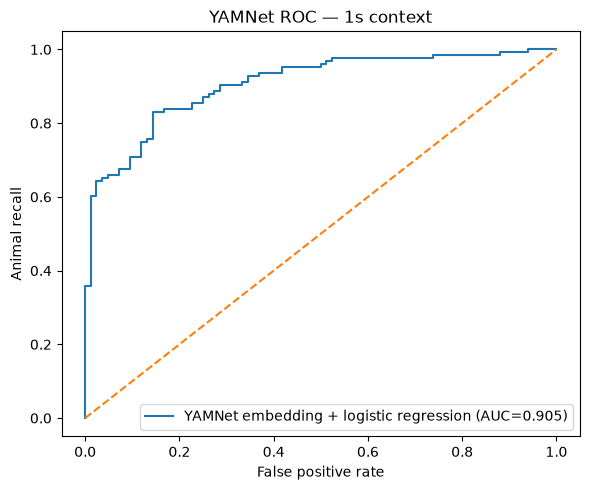

In [18]:
fpr, tpr, _ = roc_curve(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr,
    tpr,
    label=(
        'YAMNet embedding + logistic regression '
        f'(AUC={roc_auc_score(y_test, test_prob):.3f})'
    ),
)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False positive rate')
plt.ylabel('Animal recall')
plt.title(f'YAMNet ROC — {CONTEXT_SECONDS:g}s context')
plt.legend()
plt.tight_layout()
plt.show()


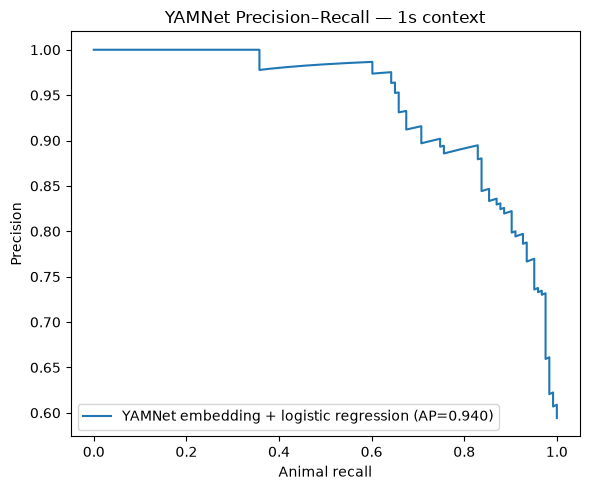

In [19]:
precision, recall, _ = precision_recall_curve(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(
    recall,
    precision,
    label=(
        'YAMNet embedding + logistic regression '
        f'(AP={average_precision_score(y_test, test_prob):.3f})'
    ),
)
plt.xlabel('Animal recall')
plt.ylabel('Precision')
plt.title(f'YAMNet Precision–Recall — {CONTEXT_SECONDS:g}s context')
plt.legend()
plt.tight_layout()
plt.show()


In [20]:
test_rows = eligible.loc[test_mask].copy()
test_rows['animal_probability'] = test_prob

site_rows = []

for site_id, group in test_rows.groupby('site_id'):
    metrics = binary_gate_metrics(
        group['binary_label'].to_numpy(),
        group['animal_probability'].to_numpy(),
        transfer_threshold,
    )

    site_rows.append({
        'site_id': site_id,
        'samples': len(group),
        'animal_samples': int((group['binary_label'] == 1).sum()),
        'background_samples': int((group['binary_label'] == 0).sum()),
        **metrics,
    })

site_results = pd.DataFrame(site_rows)

display(site_results[[
    'site_id', 'samples', 'animal_samples', 'background_samples',
    'animal_recall', 'false_negative_rate', 'background_rejection',
    'overall_vision_skip_rate', 'safe_vision_skip_rate',
]].round(4))


,site_id,samples,animal_samples,background_samples,animal_recall,false_negative_rate,background_rejection,overall_vision_skip_rate,safe_vision_skip_rate
0,S1,48,42,6,0.9524,0.0476,0.0000,0.0417,0.0000
1,S2,47,38,9,1.0000,0.0000,0.0000,0.0000,0.0000
2,S3,112,43,69,0.9767,0.0233,0.5072,0.3214,0.3125


In [21]:
results = pd.DataFrame([
    {
        'model': 'yamnet_zero_shot_animal_score',
        'context_s': CONTEXT_SECONDS,
        'split': 'validation',
        'roc_auc': roc_auc_score(y_val, zero_val),
        'pr_auc': average_precision_score(y_val, zero_val),
        **zero_val_metrics,
    },
    {
        'model': 'yamnet_zero_shot_animal_score',
        'context_s': CONTEXT_SECONDS,
        'split': 'test',
        'roc_auc': roc_auc_score(y_test, zero_test),
        'pr_auc': average_precision_score(y_test, zero_test),
        **zero_test_metrics,
    },
    {
        'model': 'yamnet_embedding_logreg',
        'context_s': CONTEXT_SECONDS,
        'split': 'validation',
        'roc_auc': roc_auc_score(y_val, val_prob),
        'pr_auc': average_precision_score(y_val, val_prob),
        **val_metrics,
    },
    {
        'model': 'yamnet_embedding_logreg',
        'context_s': CONTEXT_SECONDS,
        'split': 'test',
        'roc_auc': roc_auc_score(y_test, test_prob),
        'pr_auc': average_precision_score(y_test, test_prob),
        **test_metrics,
    },
])

results.to_csv(METRICS_PATH, index=False)

config = {
    'yamnet_handle': YAMNET_HANDLE,
    'yamnet_sample_rate': YAMNET_SAMPLE_RATE,
    'context_seconds': CONTEXT_SECONDS,
    'embedding_pool': EMBEDDING_POOL,
    'target_animal_recall': TARGET_ANIMAL_RECALL,
    'random_seed': RANDOM_SEED,
    'zero_shot_threshold': zero_threshold,
    'transfer_threshold': transfer_threshold,
}

CONFIG_PATH.write_text(json.dumps(config, indent=2))
site_results.to_csv(
    RESULTS_DIR / f'yamnet_site_results_{CONTEXT_TAG}s.csv',
    index=False,
)

print('Saved:')
print(' -', METRICS_PATH)
print(' -', CONFIG_PATH)
print(' -', MODEL_PATH)

display(results.round(4))

Saved:
 - results\yamnet_metrics_1p0s.csv
 - results\yamnet_config_1p0s.json
 - models\yamnet_logreg_1p0s.joblib


,model,context_s,split,roc_auc,pr_auc,threshold,accuracy,precision_animal,animal_recall,false_negative_rate,f1_animal,background_rejection,overall_vision_skip_rate,safe_vision_skip_rate,tn,fp,fn,tp
0,yamnet_zero_shot_animal_score,1.0,validation,0.6313,0.8532,0.0000,0.7655,0.7914,0.9565,0.0435,0.8661,0.0333,0.0414,0.0069,1,29,5,110
1,yamnet_zero_shot_animal_score,1.0,test,0.6528,0.7267,0.0000,0.5894,0.5931,0.9837,0.0163,0.7401,0.0119,0.0145,0.0048,1,83,2,121
2,yamnet_embedding_logreg,1.0,validation,0.8548,0.9541,0.1079,0.7931,0.8148,0.9565,0.0435,0.8800,0.1667,0.0690,0.0345,5,25,5,110
3,yamnet_embedding_logreg,1.0,test,0.9053,0.9396,0.1079,0.7488,0.7101,0.9756,0.0244,0.8219,0.4167,0.1836,0.1691,35,49,3,120
